<a href="https://colab.research.google.com/github/PoreddyRani/Opencv-lab/blob/main/exp13(Motion_Detection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screen Recording 2026-04-16 125915.mp4 to Screen Recording 2026-04-16 125915 (1).mp4


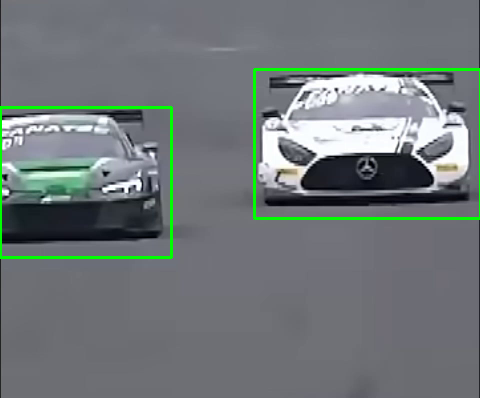

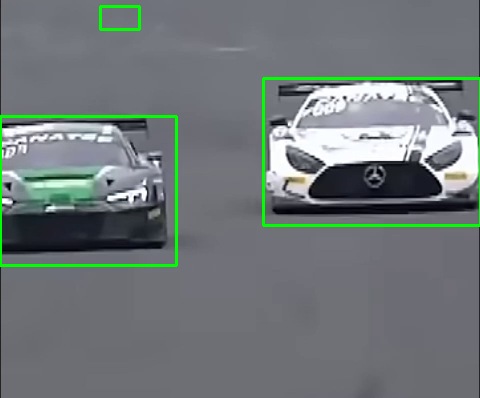

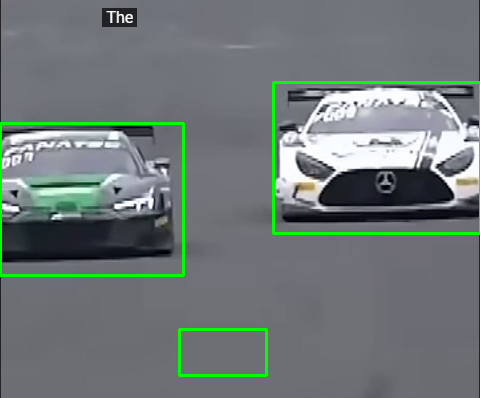

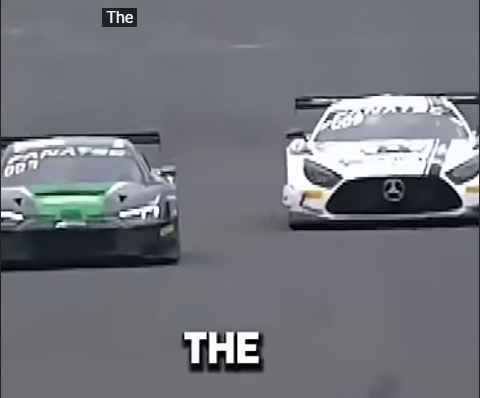

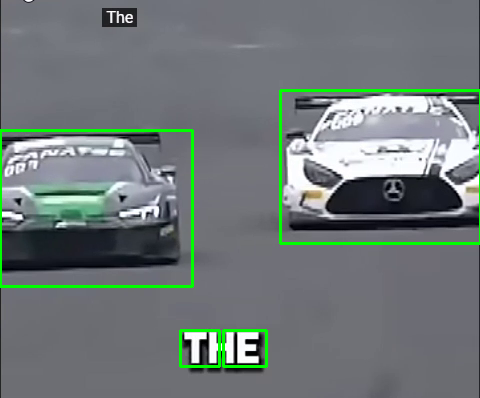

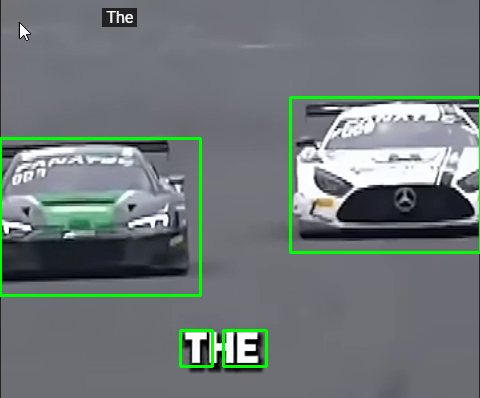

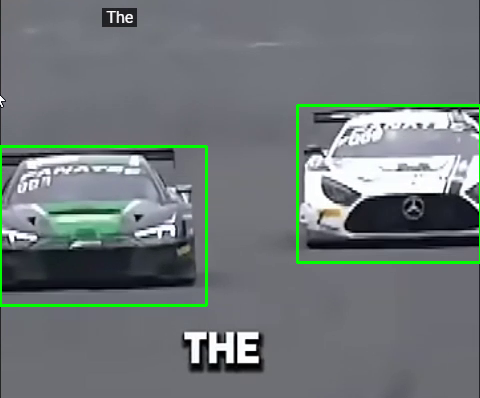

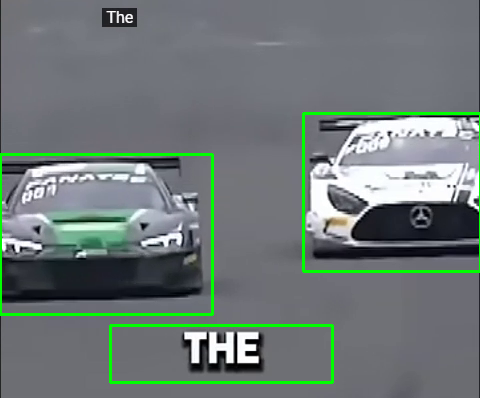

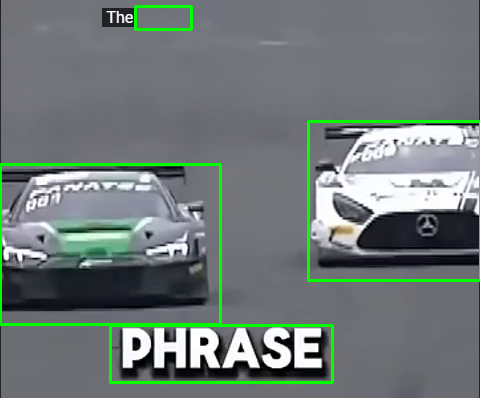

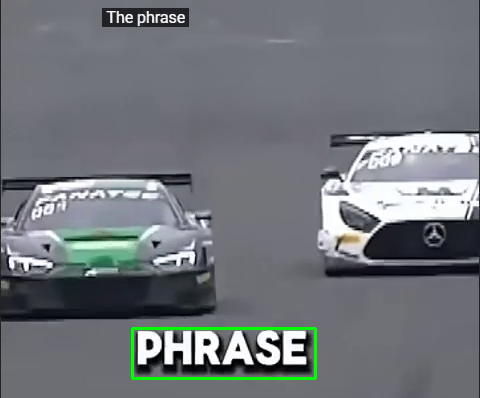

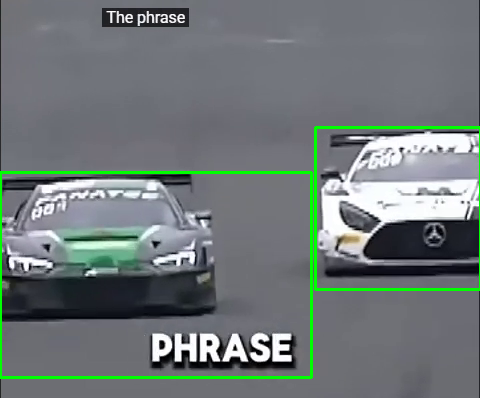

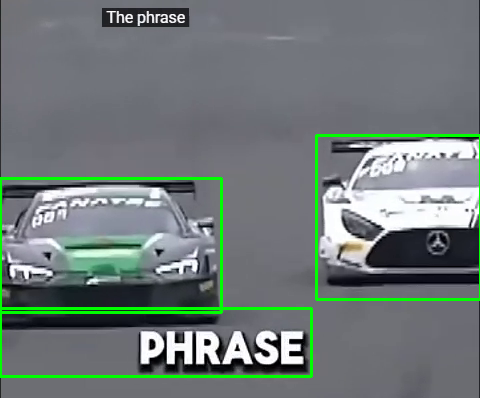

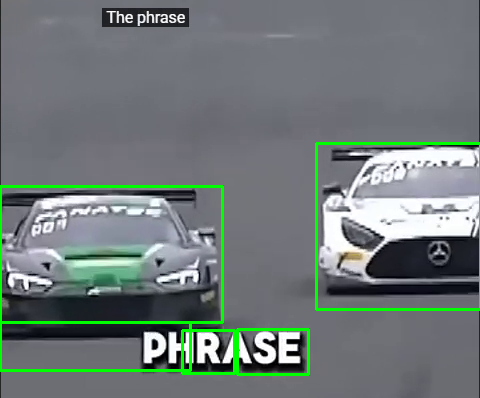

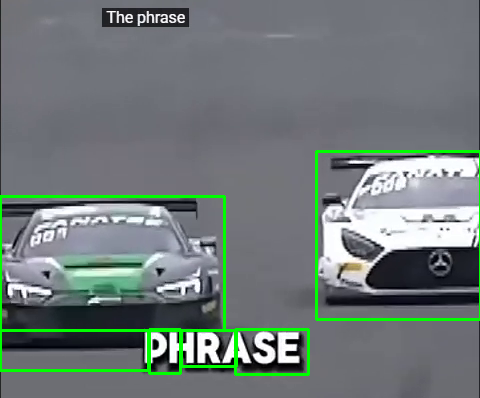

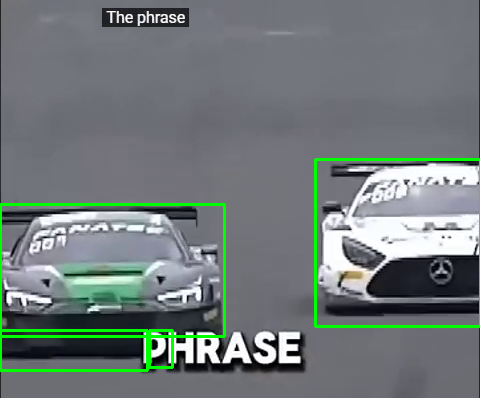

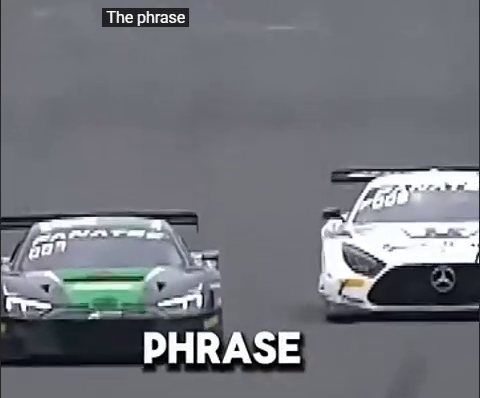

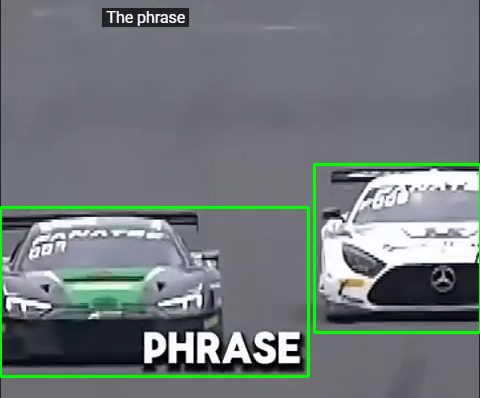

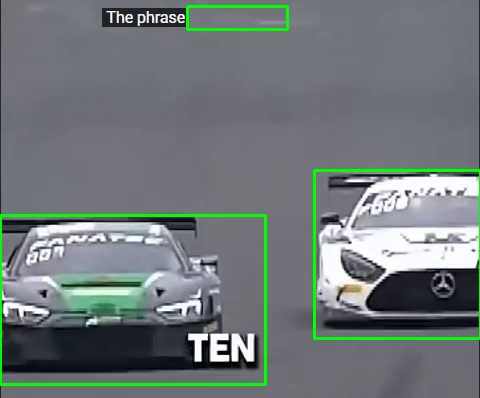

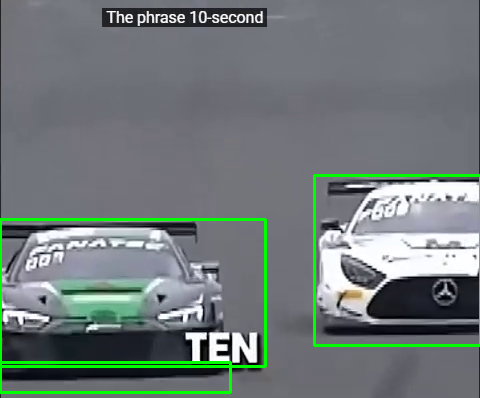

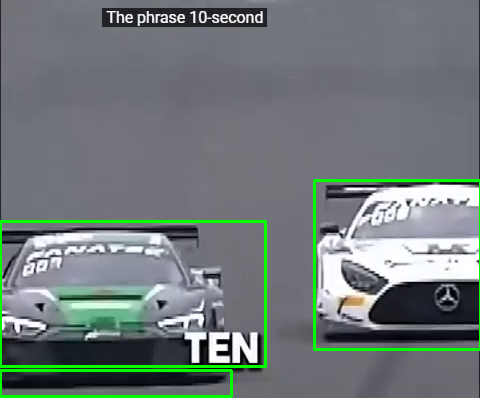

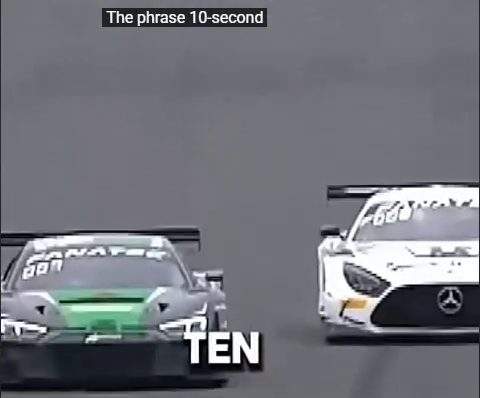

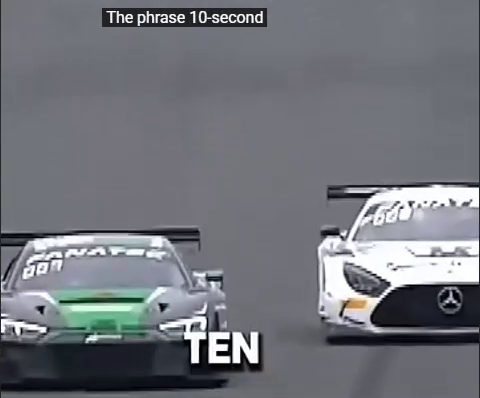

In [ ]:
!pip install opencv-python-headless

import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload video
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

while ret:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(gray1, gray2)
    _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
    thresh = cv2.dilate(thresh, None, iterations=2)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(frame1, (x,y), (x+w,y+h), (0,255,0), 2)

    # IMPORTANT: use this in Colab
    cv2_imshow(frame1)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

    frame1 = frame2
    ret, frame2 = cap.read()

cap.release()
cv2.destroyAllWindows()
